# Preliminaries

In [45]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
pwd

'/content/drive/My Drive/lab8'

In [47]:
cd /content/drive/MyDrive/lab8

/content/drive/MyDrive/lab8


In [48]:
ls

FiveK.csv


In [49]:
from datascience import *
import numpy as np
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

# Problem 1

In [50]:
#Read in the dataset
fiveK = Table.read_table('FiveK.csv')

In [51]:
# Display variable names
fiveK.labels

('Run',
 'Finishing Time In Minutes',
 'Identifies As Female',
 'Age',
 'Name',
 'City',
 'State')

In [52]:
# Display number of rows
fiveK.num_rows

656

# Problem 2

Suppose we wish to perform an A/B test of the null hypothesis that the hypothetical average male time in this race equals the hypothetical average female time in this race, among all 5K runners. The alternative will reflect that the male runners are faster than the female runners. In this problem, you should state the hypotheses, state your test statistic (mainly interested in the order in which you will subtract), and simulate the sampling distribution of the test statistic. For this purpose, you can use the difference_of_means function from Section 12.1.

|

Define your null hypothesis: The average male time in the 5K race is equal to the average female time.

Define your alternative hypothesis: The average male time in the 5K race is less than the average female time.

State the test statistc. In particular, specify the order of subtraction: mean(female times) - mean(male times).

|

Now, we will simulate the sampling distribution of the test statistic under the null. To do this, modify the code below.

In [53]:
group_labels = fiveK.select('Identifies As Female')

In [54]:
'''We are going compute such differences repeatedly in our simulations below,
so we will define a function to do the job. The function takes two arguments:
     - the name of the table of data
     - the label of the column that contains the Boolean variable for grouping
      It returns the difference between the means of the True group and the False group
'''

def difference_of_means(fiveK, group_label):
    reduced = fiveK.select('Finishing Time In Minutes', group_label)
    means_table = reduced.group(group_label, np.average)
    means = means_table.column(1)
    return means.item(1) - means.item(0)

In [55]:
'''
If there were no difference between the two distributions in the underlying population,
then whether Identifies as Female has the label True or False with respect to
Finishing Time should make no difference to the average. The idea, then,
is to shuffle all the labels randomly among the participants.
This is called random permutation.
'''

def one_simulated_difference_of_means():
    """Returns: Difference between mean finishing times
    of female and male runners after shuffling labels"""

    shuffled_labels = fiveK.sample(with_replacement=False).column('Identifies As Female')

    shuffled_table = fiveK.select('Finishing Time In Minutes').with_column(
        'Shuffled Label', shuffled_labels)

    return difference_of_means(shuffled_table, 'Shuffled Label')


In [56]:
# Perform this task for many repetitions
# Notice: In this version, we set up a full array with the correct number of entries as a first step.
repetitions = 5000
differences = np.empty(repetitions)

for i in np.arange(repetitions):
    differences[i] = one_simulated_difference_of_means()

# Problem 3

Plot the histogram of mean differences that you obtain by simulation under the null hypothesis of no mean difference. Compare this histogram to the value observed in the sample, calculate a p-value, and comment on what this p-value tells you in this case about whether we should reject the null hypothesis. Write a conclusion sentence that conveys what you have discovered to an audience unfamiliar with statistical terminology. The conclusion should be written in the context of the problem.

Some code is provided below. You may need to modify and/or add additional pieces to this. In particular, you will have to find the observed value of the test statistic and may want to name it observed_difference since that is reference in the code below.

In [57]:
observed_difference = difference_of_means(fiveK, 'Identifies As Female')

Observed Difference: 4.590877527994813


Text(0.5, 1.0, 'Prediction Under the Null Hypothesis')

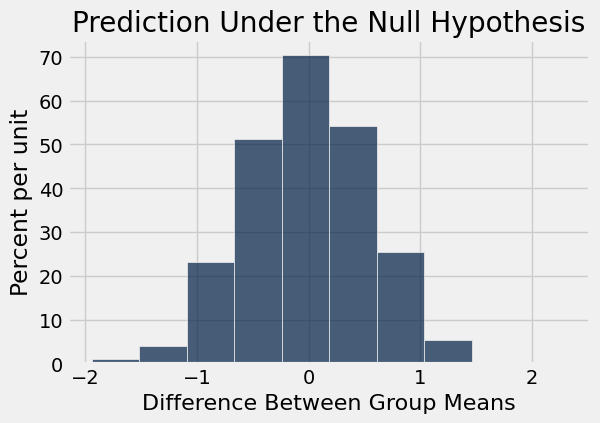

In [58]:
Table().with_column('Difference Between Group Means', differences).hist()
print('Observed Difference:', observed_difference)
plots.title('Prediction Under the Null Hypothesis')

In [59]:
# observed value corresponds to the original mean difference before NULL hypothesis is performed
# refer to section  12.1 from textbook if needed
empirical_p = np.count_nonzero(differences <= observed_difference) / repetitions
empirical_p

1.0

# Problem 4

Just as in Section 13.2, it will be possible to use the sample() method with no arguments to accomplish the bootstrapping. However, there is a subtle point in this case: We should make sure that each bootstrap sample has the same number of males and females as the original, since we're finding the difference of two sample means (one female, one male) and the sample sizes are important in determining the behavior of sample means. Therefore, if you're using datascience then you'll want to create two separate Table objects, one for females and one for males, using code such as this:

In [60]:
fiveK_Male = fiveK.where('Identifies As Female', False)
fiveK_Female = fiveK.where('Identifies As Female', True)

Make sure that the pdf file you turn in somehow indicates how many female and male cases there are in the dataset. Add code below to accomplish this.

In [61]:
num_female = fiveK.where('Identifies As Female', True).num_rows
num_male = fiveK.where('Identifies As Female', False).num_rows

print("Number of Female Cases", num_female)
print("Number of Male Cases", num_male)

Number of Female Cases 293
Number of Male Cases 363


# Problem 5

Rewrite the function one_bootstrap_median in Section 13.2.6. so that it selects one bootstrap sample for females, another for males, then returns the difference of the two mean finishing times. Here is code that accomplishes this if you're using the datascience package:

In [62]:
# Now perform Bootstripping on fiveK_Male and fiveK_Female and find the mean difference
def one_bootstrap_mean_difference():
    resampled_Females = fiveK_Female.sample()
    resampled_Males = fiveK_Male.sample()
    Female_mean = np.mean(resampled_Females.column('Finishing Time In Minutes'))
    Male_mean = np.mean(resampled_Males.column('Finishing Time In Minutes'))
    bootstrapped_mean_difference =  Male_mean - Female_mean

    return bootstrapped_mean_difference

# Problem 6

Reproduce the analysis of Section 13.2.7 by creating a histogram of 5000 bootstrapped mean differences. You will have to choose histogram bins that are appropriate for this example AND there will not be a green dot showing the position of the population parameter (since in this case we do not know the population parameter).

In [63]:
def one_bootstrap_median():
    resampled_table = fiveK.sample()
    bootstrapped_median = percentile(50, resampled_table.column('Finishing Time In Minutes'))
    return bootstrapped_median

In [64]:
num_repetitions = 5000
bstrap_means = make_array()
for i in np.arange(num_repetitions):
    bstrap_means = np.append (bstrap_means, one_bootstrap_mean_difference())

In [65]:
pop_median = percentile(50, fiveK.column('Finishing Time In Minutes'))
pop_median

27.317

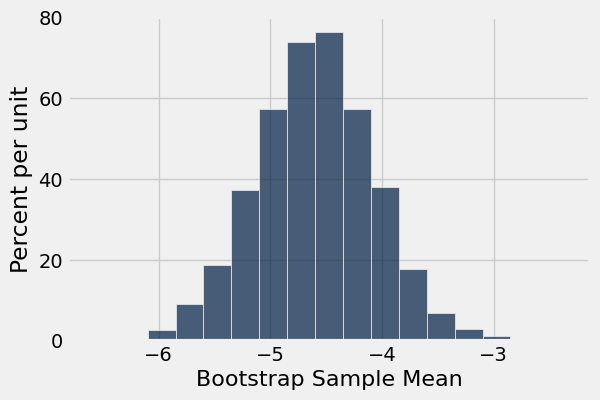

In [66]:
resampled_means = Table().with_column('Bootstrap Sample Mean', bstrap_means)
mean_bins=np.arange(-6.6, -2.1, 0.25)
resampled_means.hist(bins = mean_bins)

# Problem 7
Find the 2.5 and 97.5 percentiles of your mean difference distribution, and use these values as a 95% confidence interval.

In [67]:
lower = percentile(2.5, bstrap_means)
upper = percentile(97.5, bstrap_means)
print(lower, upper)

-5.64875500898 -3.5562573078


"We are 95%
confident that the true difference in mean 5K road race finishing times between females and males
is between -5.62 and -3.53."